In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/TA_KIM/data')
dir = os.getcwd()


Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
feat_psvmg2g3 = pd.read_csv('features_importances_psvmg2g3.txt', delimiter=' ', index_col=0)
hipo = pd.read_csv(f'{dir}/hipo_g3.txt')
hiper = pd.read_csv(f'{dir}/hiper_g3.txt')
feat_scores = pd.read_csv('features_importances_kernelSVM.txt', delimiter=' ', index_col=0)
feat_rankscore = pd.read_csv('RankSet_ALL.txt', delimiter='\t')

In [ ]:
feat_rankscore

,SYMBOL,G1,G2,G3
0,AAK1,-43.923352,-15.052787,-11.138036
1,ABCA4,-19.232563,-19.168905,-29.648150
2,ABHD12B,7.839770,19.308619,29.841985
3,ABLIM3,-23.476801,-9.263315,-10.058814
4,ACAT2,-21.950928,-23.511624,-24.195579
...,...,...,...,...
395,ZNF589,-6.207153,-13.340131,-27.209584
396,ZNF696,-8.662767,-13.830444,-28.442907
397,ZNF738,-20.897654,-19.906516,-10.501845
398,ZNF862,-13.848342,-13.301233,-26.466593


In [ ]:
hiper

,Genes
0,HOXA10
1,CYB5R2
2,HMGXB4
3,OSR2
4,ZNF232
...,...
83,LIME1
84,PAPLN
85,ERRFI1
86,PRR15


In [ ]:
feat_400 = feat_psvmg2g3.head(400)
feat_400

,G2,G3,sum
KCNQ1,0.012439,0.012439,0.024877
SLC6A6,0.007463,0.007463,0.014926
PAPLN,0.006731,0.006731,0.013463
OR8B4,0.006409,0.006409,0.012817
NEDD1,0.006096,0.006096,0.012192
...,...,...,...
CCND3,0.001196,0.001196,0.002391
ABTB2,0.001195,0.001195,0.002391
GBAP1,0.001195,0.001195,0.002391
HELQ,0.001195,0.001195,0.002389


In [ ]:
hiper_scores = feat_scores[feat_scores.index.isin(hiper['Genes'])]
hipo_scores = feat_scores[feat_scores.index.isin(hipo['Genes'])]
hipo_scores

,NT,G1,G2,G3,sum
E2F6,0.000478,0.000795,0.005097,0.002772,0.009141
PIGB,0.000619,0.002668,0.000966,0.004667,0.008920
S100A2,0.000829,0.001269,0.000975,0.005680,0.008753
NEDD1,0.000499,0.001624,0.004750,0.001837,0.008710
C1orf77,0.000329,0.000749,0.004309,0.002970,0.008357
...,...,...,...,...,...
HCG18,0.000389,0.000216,0.000315,0.000256,0.001176
IKZF2,0.000262,0.000325,0.000300,0.000287,0.001174
RCCD1,0.000486,0.000186,0.000317,0.000177,0.001165
RALGAPB,0.000303,0.000300,0.000279,0.000270,0.001153


In [ ]:
def feature_importance_plot(df_feats, colname, title, bar_color='blue'):
    # Filter to keep only the specified column
    df_sort = df_feats[[colname]].sort_values(by=colname, ascending=False)

    # Select the top 10 rows and reverse the order
    df_excluded = df_sort.head(10).iloc[::-1]

    # Plotting the normal bar chart with specified color
    ax = df_excluded.plot(kind='barh', figsize=(2.5, 5), legend=False, color=bar_color)

    # Adding title and labels
    ax.set_title(title)
    ax.set_xlabel('Feature Importance Score', fontsize=12)
    ax.set_ylabel('Genes')
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=10)

    # Show plot
    plt.show()
    df_excluded = df_excluded.sort_values(by=colname, ascending=False)
    return df_excluded

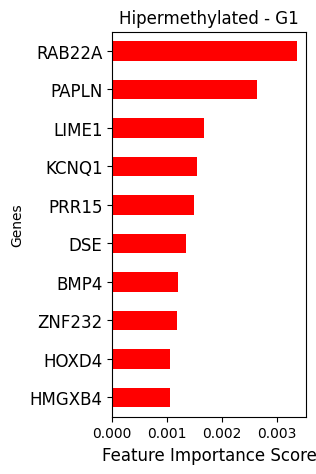

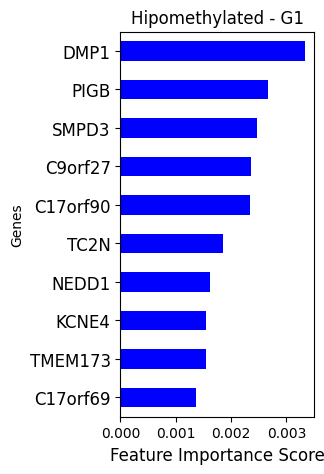

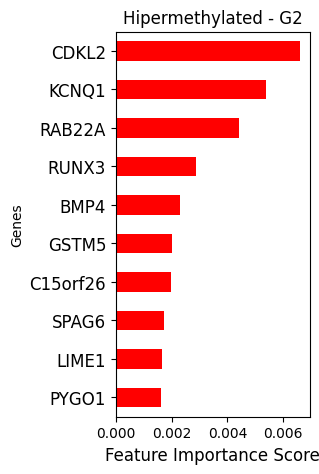

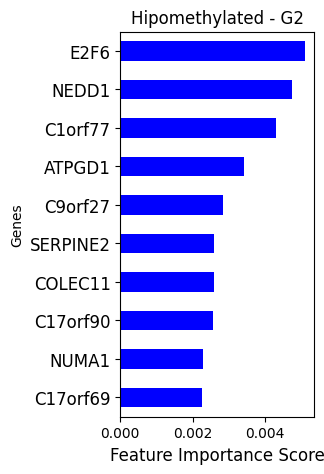

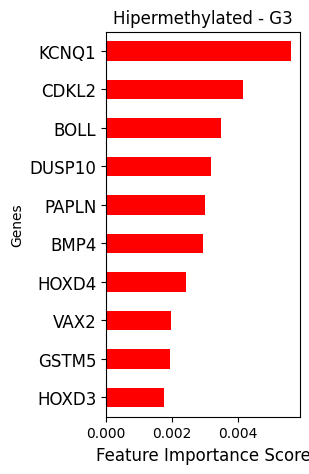

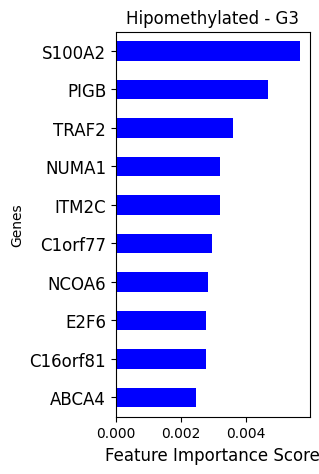

In [ ]:
hiper_g1 = feature_importance_plot(hiper_scores, 'G1','Hipermethylated - G1', 'red')
hipo_g1 = feature_importance_plot(hipo_scores, 'G1','Hipomethylated - G1', 'blue')
hiper_g2 = feature_importance_plot(hiper_scores, 'G2','Hipermethylated - G2', 'red')
hipo_g2 = feature_importance_plot(hipo_scores, 'G2','Hipomethylated - G2', 'blue')
hiper_g3  = feature_importance_plot(hiper_scores, 'G3','Hipermethylated - G3', 'red')
hipo_g3  = feature_importance_plot(hipo_scores, 'G3','Hipomethylated - G3', 'blue')


In [ ]:
hipo_g1_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hipo_g1.index)]
hipo_g2_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hipo_g2.index)]
hipo_g3_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hipo_g3.index)]
hiper_g1_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hiper_g1.index)]
hiper_g2_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hiper_g2.index)]
hiper_g3_rank = feat_rankscore[feat_rankscore['SYMBOL'].isin(hiper_g3.index)]

In [ ]:
#hipo_g1['Genes'] = hipo_g1.index
#hipo_g1 = hipo_g1.reset_index(drop=True)
#hipo_g1
def new_column_reset_index(df):
    df['Genes'] = df.index
    df = df.reset_index(drop=True)
    return df

In [ ]:
hipo_g1 = new_column_reset_index(hipo_g1)
hipo_g2 = new_column_reset_index(hipo_g2)
hipo_g3 = new_column_reset_index(hipo_g3)
hiper_g1 = new_column_reset_index(hiper_g1)
hiper_g2 = new_column_reset_index(hiper_g2)
hiper_g3 = new_column_reset_index(hiper_g3)

In [ ]:
def mapping_features(df, df_ref):
  df['SYMBOL'] = pd.Categorical(df['SYMBOL'], categories=df_ref['Genes'], ordered=True)
  df_sorted = df.sort_values('SYMBOL')
  df_sorted.reset_index(drop=True, inplace=True)
  return df_sorted

In [ ]:
hipo_g1_filter = mapping_features(hipo_g1_rank, hipo_g1).round(2)
hipo_g2_filter = mapping_features(hipo_g2_rank, hipo_g2).round(2)
hipo_g3_filter = mapping_features(hipo_g3_rank, hipo_g3).round(2)
hiper_g1_filter = mapping_features(hiper_g1_rank, hiper_g1).round(2)
hiper_g2_filter = mapping_features(hiper_g2_rank, hiper_g2).round(2)
hiper_g3_filter = mapping_features(hiper_g3_rank, hiper_g3).round(2)

<ipython-input-15-dbfb590f5a17>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SYMBOL'] = pd.Categorical(df['SYMBOL'], categories=df_ref['Genes'], ordered=True)
<ipython-input-15-dbfb590f5a17>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SYMBOL'] = pd.Categorical(df['SYMBOL'], categories=df_ref['Genes'], ordered=True)
<ipython-input-15-dbfb590f5a17>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [ ]:
import copy
hipo_round = copy.deepcopy(hipo_g1_filter)
hipo_round = hipo_round.round(2)
hipo_round

,SYMBOL,G1,G2,G3
0,DMP1,-41.63,-29.79,-20.96
1,PIGB,-0.29,-10.49,-26.88
2,SMPD3,-17.88,-2.16,-0.77
3,C9orf27,-27.28,-7.28,-12.24
4,C17orf90,-6.78,-40.79,-42.67
5,TC2N,-53.65,-29.51,-14.57
6,NEDD1,-26.56,-34.79,-46.16
7,KCNE4,-68.62,-46.70,-29.30
8,TMEM173,-34.46,-20.18,-7.26
9,C17orf69,-26.21,-28.68,-14.73


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def create_heatmap(data, title, color_scheme='blue', cell_fontsize=10, xticklabel_fontsize=10, yticklabel_fontsize=10):
    # Normalize the data per row
    scaler = MinMaxScaler()
    normalized_data = data.copy()
    normalized_data.iloc[:, 1:] = scaler.fit_transform(data.iloc[:, 1:].values.T).T

    # Choose the color map based on the input parameter
    if color_scheme == 'blue':
        cmap = "Blues_r"  # Reversed Blues color map
    elif color_scheme == 'red':
        cmap = "Reds"  # Reds color map

    # Create the heatmap
    plt.figure(figsize=(4, 5))
    ax = sns.heatmap(normalized_data.iloc[:, 1:],
                     annot=data.iloc[:, 1:],
                     fmt='',  # Display the actual values without formatting
                     cmap=cmap,  # Use the chosen color map
                     cbar_kws={'label': 'Min-Max Normalized -log(p-val)*sign(logFC)'},
                     yticklabels=data['SYMBOL'],
                     annot_kws={'fontsize': cell_fontsize})

    # Customize the heatmap
    ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=xticklabel_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=yticklabel_fontsize)
    plt.title(title)
    plt.show()

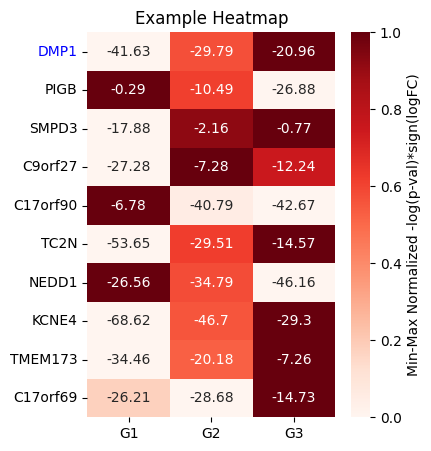

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def create_heatmap(data, title, color_scheme='blue', cell_fontsize=10, xticklabel_fontsize=10, yticklabel_fontsize=10, red_blue_font=None, yellow_font=None):
    # Normalize the data per row
    scaler = MinMaxScaler()
    normalized_data = data.copy()
    normalized_data.iloc[:, 1:] = scaler.fit_transform(data.iloc[:, 1:].values.T).T

    # Choose the color map based on the input parameter
    if color_scheme == 'blue':
        cmap = "Blues_r"  # Reversed Blues color map
    elif color_scheme == 'red':
        cmap = "Reds"  # Reds color map

    # Create the heatmap
    plt.figure(figsize=(4, 5))
    ax = sns.heatmap(normalized_data.iloc[:, 1:],
                     annot=data.iloc[:, 1:],
                     fmt='',  # Display the actual values without formatting
                     cmap=cmap,  # Use the chosen color map
                     cbar_kws={'label': 'Min-Max Normalized -log(p-val)*sign(logFC)'},
                     yticklabels=data['SYMBOL'],
                     annot_kws={'fontsize': cell_fontsize})

    # Customize the heatmap
    ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='center', fontsize=xticklabel_fontsize)

    # Conditional font colors for yticklabels
    if red_blue_font is None:
        red_blue_font = []
    if yellow_font is None:
        yellow_font = []

    for tick_label in ax.get_yticklabels():
        label_text = tick_label.get_text()
        if label_text in red_blue_font:
            if color_scheme == 'blue':
                tick_label.set_color('red')
            elif color_scheme == 'red':
                tick_label.set_color('blue')
        elif label_text in yellow_font:
            tick_label.set_color('yellow')
        else:
            tick_label.set_color('black')
        tick_label.set_fontsize(yticklabel_fontsize)

    plt.title(title)
    plt.show()

# Example usage
data = pd.DataFrame({
    'SYMBOL': ['DMP1', 'PIGB', 'SMPD3', 'C9orf27', 'C17orf90', 'TC2N', 'NEDD1', 'KCNE4', 'TMEM173', 'C17orf69'],
    'G1': [-41.63, -0.29, -17.88, -27.28, -6.78, -53.65, -26.56, -68.62, -34.46, -26.21],
    'G2': [-29.79, -10.49, -2.16, -7.28, -40.79, -29.51, -34.79, -46.70, -20.18, -28.68],
    'G3': [-20.96, -26.88, -0.77, -12.24, -42.67, -14.57, -46.16, -29.30, -7.26, -14.73]
})

# Call the function with the new parameters
create_heatmap(data,
               title="Example Heatmap",
               color_scheme='red',
               cell_fontsize=10,
               xticklabel_fontsize=10,
               yticklabel_fontsize=10,
               red_blue_font=['DMP1', 'BMP4', 'ZNF232', 'SPAG6', 'HOXD3', 'HOXD4', 'VAX2'],
               yellow_font=['HMGXB4'])

In [ ]:
print(hipo_g1_filter)

     SYMBOL     G1     G2     G3
0      DMP1 -41.63 -29.79 -20.96
1      PIGB  -0.29 -10.49 -26.88
2     SMPD3 -17.88  -2.16  -0.77
3   C9orf27 -27.28  -7.28 -12.24
4  C17orf90  -6.78 -40.79 -42.67
5      TC2N -53.65 -29.51 -14.57
6     NEDD1 -26.56 -34.79 -46.16
7     KCNE4 -68.62 -46.70 -29.30
8   TMEM173 -34.46 -20.18  -7.26
9  C17orf69 -26.21 -28.68 -14.73


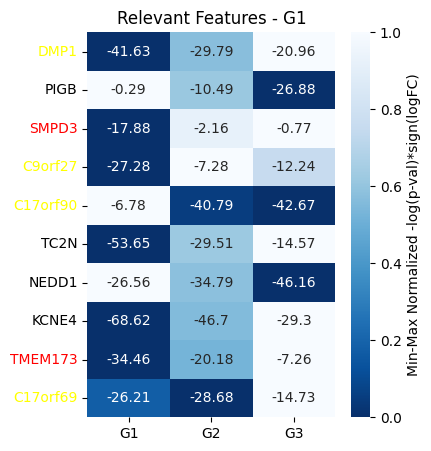

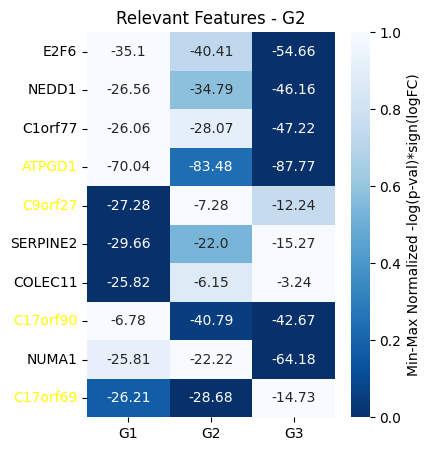

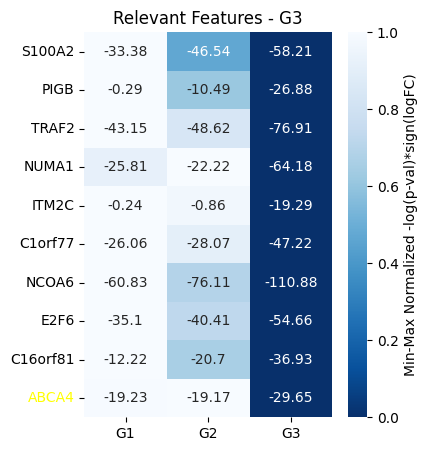

In [ ]:
blue_hiper =['RAB22A', 'BMP4', 'ZNF232', 'SPAG6', 'HOXD3', 'HOXD4', 'VAX2']
yellow_hiper=['HMGXB4']
red_hipo = ['SMPD3', 'TMEM173']
yellow_hipo = ['DMP1', 'C17orf90', 'C17orf69', 'C9orf27', 'ABCA4', 'ATPGD1']

create_heatmap(hipo_g1_filter, 'Relevant Features - G1', red_blue_font = red_hipo, yellow_font = yellow_hipo)
create_heatmap(hipo_g2_filter, 'Relevant Features - G2',red_blue_font = red_hipo, yellow_font = yellow_hipo)
create_heatmap(hipo_g3_filter, 'Relevant Features - G3',red_blue_font = red_hipo, yellow_font = yellow_hipo)

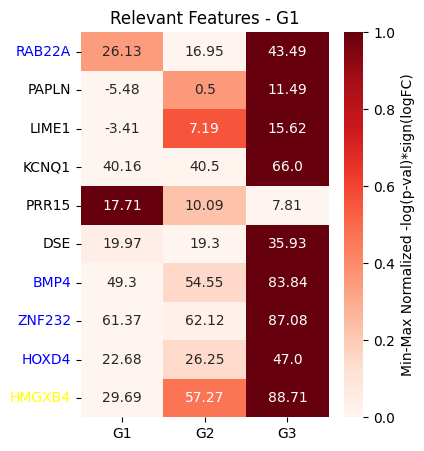

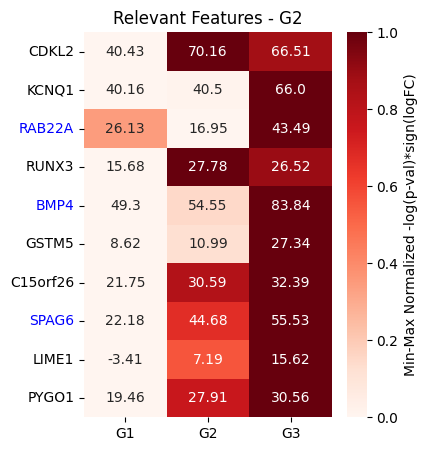

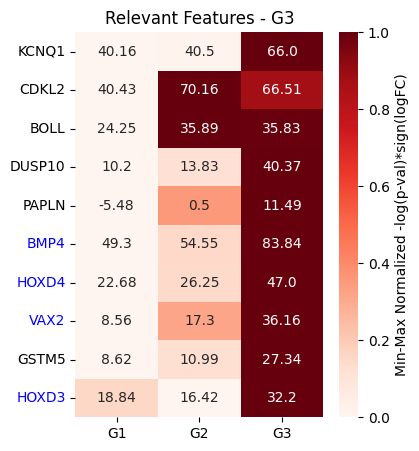

In [ ]:
create_heatmap(hiper_g1_filter, 'Relevant Features - G1', color_scheme='red',  red_blue_font = blue_hiper, yellow_font = yellow_hiper)
create_heatmap(hiper_g2_filter, 'Relevant Features - G2', color_scheme='red', red_blue_font = blue_hiper, yellow_font = yellow_hiper)
create_heatmap(hiper_g3_filter, 'Relevant Features - G3', color_scheme='red', red_blue_font = blue_hiper, yellow_font = yellow_hiper)

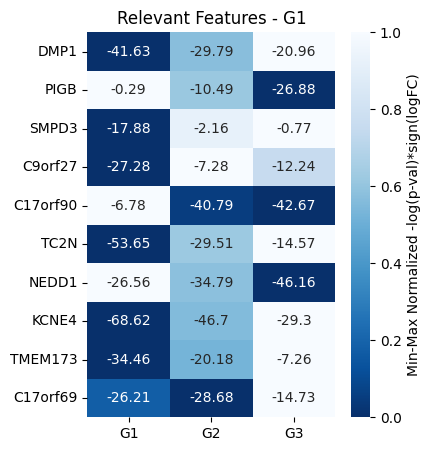

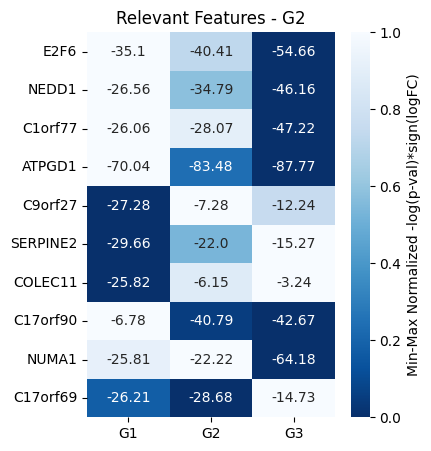

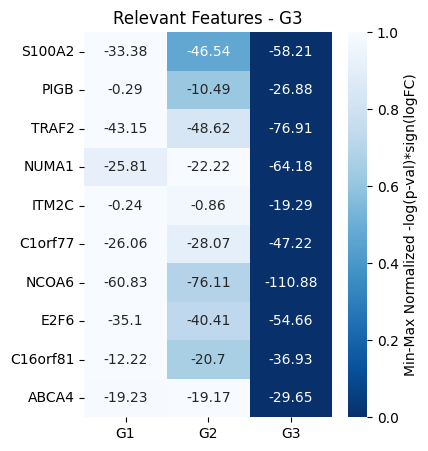

In [ ]:
create_heatmap(hipo_g1_filter, 'Relevant Features - G1')
create_heatmap(hipo_g2_filter, 'Relevant Features - G2')
create_heatmap(hipo_g3_filter, 'Relevant Features - G3')

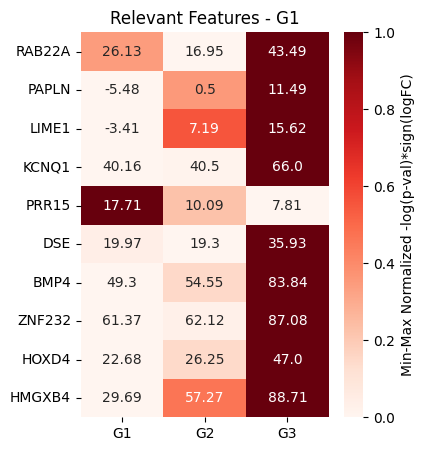

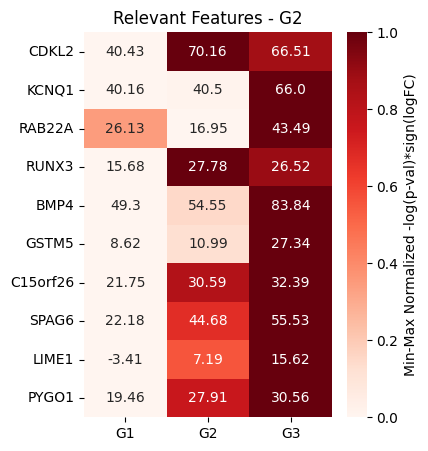

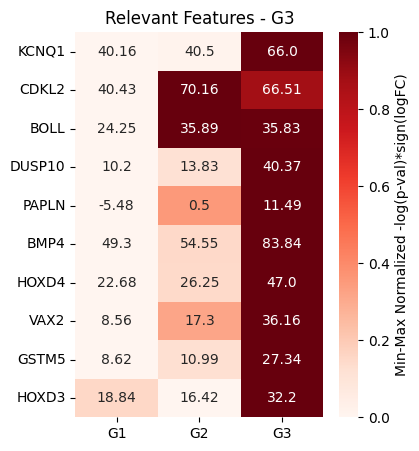

In [ ]:
create_heatmap(hiper_g1_filter, 'Relevant Features - G1', color_scheme='red')
create_heatmap(hiper_g2_filter, 'Relevant Features - G2', color_scheme='red')
create_heatmap(hiper_g3_filter, 'Relevant Features - G3', color_scheme='red')

In [ ]:
g1_importance = pd.concat([hiper_g1_filter, hipo_g1_filter], axis=0).reset_index(drop=True)
g2_importance = pd.concat([hiper_g2_filter, hipo_g2_filter], axis=0).reset_index(drop=True)
g3_importance = pd.concat([hiper_g3_filter, hipo_g3_filter], axis=0).reset_index(drop=True)

In [ ]:
g1_importance

,SYMBOL,G1,G2,G3
0,RAB22A,26.13,16.95,43.49
1,PAPLN,-5.48,0.50,11.49
2,LIME1,-3.41,7.19,15.62
3,KCNQ1,40.16,40.50,66.00
4,PRR15,17.71,10.09,7.81
5,DSE,19.97,19.30,35.93
6,BMP4,49.30,54.55,83.84
7,ZNF232,61.37,62.12,87.08
8,HOXD4,22.68,26.25,47.00
9,HMGXB4,29.69,57.27,88.71


In [ ]:
g1_importance.to_csv('g1_importance.txt', sep=' ', index=False)
g2_importance.to_csv('g2_importance.txt', sep=' ', index=False)
g3_importance.to_csv('g3_importance.txt', sep=' ', index=False)


In [ ]:
hiper_g3_filter

,SYMBOL,G1,G2,G3
0,KCNQ1,40.16,40.50,66.00
1,CDKL2,40.43,70.16,66.51
2,BOLL,24.25,35.89,35.83
3,DUSP10,10.20,13.83,40.37
4,PAPLN,-5.48,0.50,11.49
5,BMP4,49.30,54.55,83.84
6,HOXD4,22.68,26.25,47.00
7,VAX2,8.56,17.30,36.16
8,GSTM5,8.62,10.99,27.34
9,HOXD3,18.84,16.42,32.20


In [ ]:
# Combine indices
df_hiper = pd.concat([hiper_g1['Genes'], hiper_g2['Genes'], hiper_g3['Genes']])
df_hipo = pd.concat([hipo_g1['Genes'], hipo_g2['Genes'], hipo_g3['Genes']])

# Get unique values
df_hiper = df_hiper.unique()
df_hipo = df_hipo.unique()
print(len(df_hiper))
print(len(df_hipo))

20
22


In [ ]:
df_hiper

array(['RAB22A', 'PAPLN', 'LIME1', 'KCNQ1', 'PRR15', 'DSE', 'BMP4',
       'ZNF232', 'HOXD4', 'HMGXB4', 'CDKL2', 'RUNX3', 'GSTM5', 'C15orf26',
       'SPAG6', 'PYGO1', 'BOLL', 'DUSP10', 'VAX2', 'HOXD3'], dtype=object)

In [ ]:
merged_hiper_df = hiper_g1.merge(hiper_g2, on='Genes', how='inner').merge(hiper_g3, on='Genes', how='inner')
merged_hipo_df = hipo_g1.merge(hipo_g2, on='Genes', how='inner').merge(hipo_g3, on='Genes', how='inner')


In [ ]:
print(df_hipo)

['DMP1' 'PIGB' 'SMPD3' 'C9orf27' 'C17orf90' 'TC2N' 'NEDD1' 'KCNE4'
 'TMEM173' 'C17orf69' 'E2F6' 'C1orf77' 'ATPGD1' 'SERPINE2' 'COLEC11'
 'NUMA1' 'S100A2' 'TRAF2' 'ITM2C' 'NCOA6' 'C16orf81' 'ABCA4']


In [ ]:
hiper_g1

,G1,Genes
0,0.003362,RAB22A
1,0.002628,PAPLN
2,0.001664,LIME1
3,0.001553,KCNQ1
4,0.001489,PRR15
5,0.001347,DSE
6,0.001198,BMP4
7,0.001180,ZNF232
8,0.001055,HOXD4
9,0.001047,HMGXB4


In [ ]:
print(df_hipo)

['DMP1' 'PIGB' 'SMPD3' 'C9orf27' 'C17orf90' 'TC2N' 'NEDD1' 'KCNE4'
 'TMEM173' 'C17orf69' 'E2F6' 'C1orf77' 'ATPGD1' 'SERPINE2' 'COLEC11'
 'NUMA1' 'S100A2' 'TRAF2' 'ITM2C' 'NCOA6' 'C16orf81' 'ABCA4']


In [ ]:
all_genes_in_index = hiper['Genes'].isin(feat_400.index).all()
print(all_genes_in_index)

False


In [ ]:
hiper['Genes'].isin(feat_400.index).all()

False

In [ ]:
feat_scores

,NT,G1,G2,G3,sum
KCNQ1,0.000510,0.001553,0.005397,0.005586,0.013046
CDKL2,0.000547,0.000598,0.006621,0.004143,0.011909
RAB22A,0.000257,0.003362,0.004426,0.001139,0.009185
E2F6,0.000478,0.000795,0.005097,0.002772,0.009141
PIGB,0.000619,0.002668,0.000966,0.004667,0.008920
...,...,...,...,...,...
ATP1B3,0.000141,0.000277,0.000259,0.000357,0.001035
NEK5,0.000286,0.000138,0.000295,0.000315,0.001033
BHLHE40,0.000308,0.000099,0.000321,0.000290,0.001018
SRP54,0.000167,0.000313,0.000280,0.000256,0.001016


In [ ]:
feat_scores

,NT,G1,G2,G3,sum
KCNQ1,0.000510,0.001553,0.005397,0.005586,0.013046
CDKL2,0.000547,0.000598,0.006621,0.004143,0.011909
RAB22A,0.000257,0.003362,0.004426,0.001139,0.009185
E2F6,0.000478,0.000795,0.005097,0.002772,0.009141
PIGB,0.000619,0.002668,0.000966,0.004667,0.008920
...,...,...,...,...,...
ATP1B3,0.000141,0.000277,0.000259,0.000357,0.001035
NEK5,0.000286,0.000138,0.000295,0.000315,0.001033
BHLHE40,0.000308,0.000099,0.000321,0.000290,0.001018
SRP54,0.000167,0.000313,0.000280,0.000256,0.001016
